In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
from scipy.integrate import quad
import torch
from torch import nn
from datetime import datetime
from matplotlib.gridspec import GridSpec
from tensorboard.backend.event_processing import event_accumulator

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CallbackList, EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../")

In [3]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

### Parameters

In [9]:
max_inventory = 20

seed = 42

In [10]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [11]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi = compute_psi(fads_proportion)

print("psi value:", psi)

psi value: 14.872283180889763


In [12]:
def get_closed_form_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

#### Cartea Jaimungal Agent

In [13]:
cj_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [14]:
cj_agent = ModifiedCarteaJaimungalMmAgent(env=cj_env)
print(cj_env.model_dynamics
      .midprice_model)


In [15]:
num_trajectories = 1000
vec_cj_env = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_cj = ModifiedCarteaJaimungalMmAgent(env=vec_cj_env)

print(vec_cj_env.model_dynamics
      .midprice_model)

In [16]:
observations_cj, actions_cj, rewards_cj = generate_trajectory(vec_cj_env, vec_cj)

In [17]:
results_cj, fig_cj, total_rewards_cj = generate_results_table_and_hist(vec_env=vec_cj_env,agent=vec_cj)

In [18]:
results_cj

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065896,21.133681,4.809688,-0.071,3.106116


#### Full Information Agent

In [19]:
fi_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [20]:
fi_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=fi_env)
print(fi_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 1000 time points


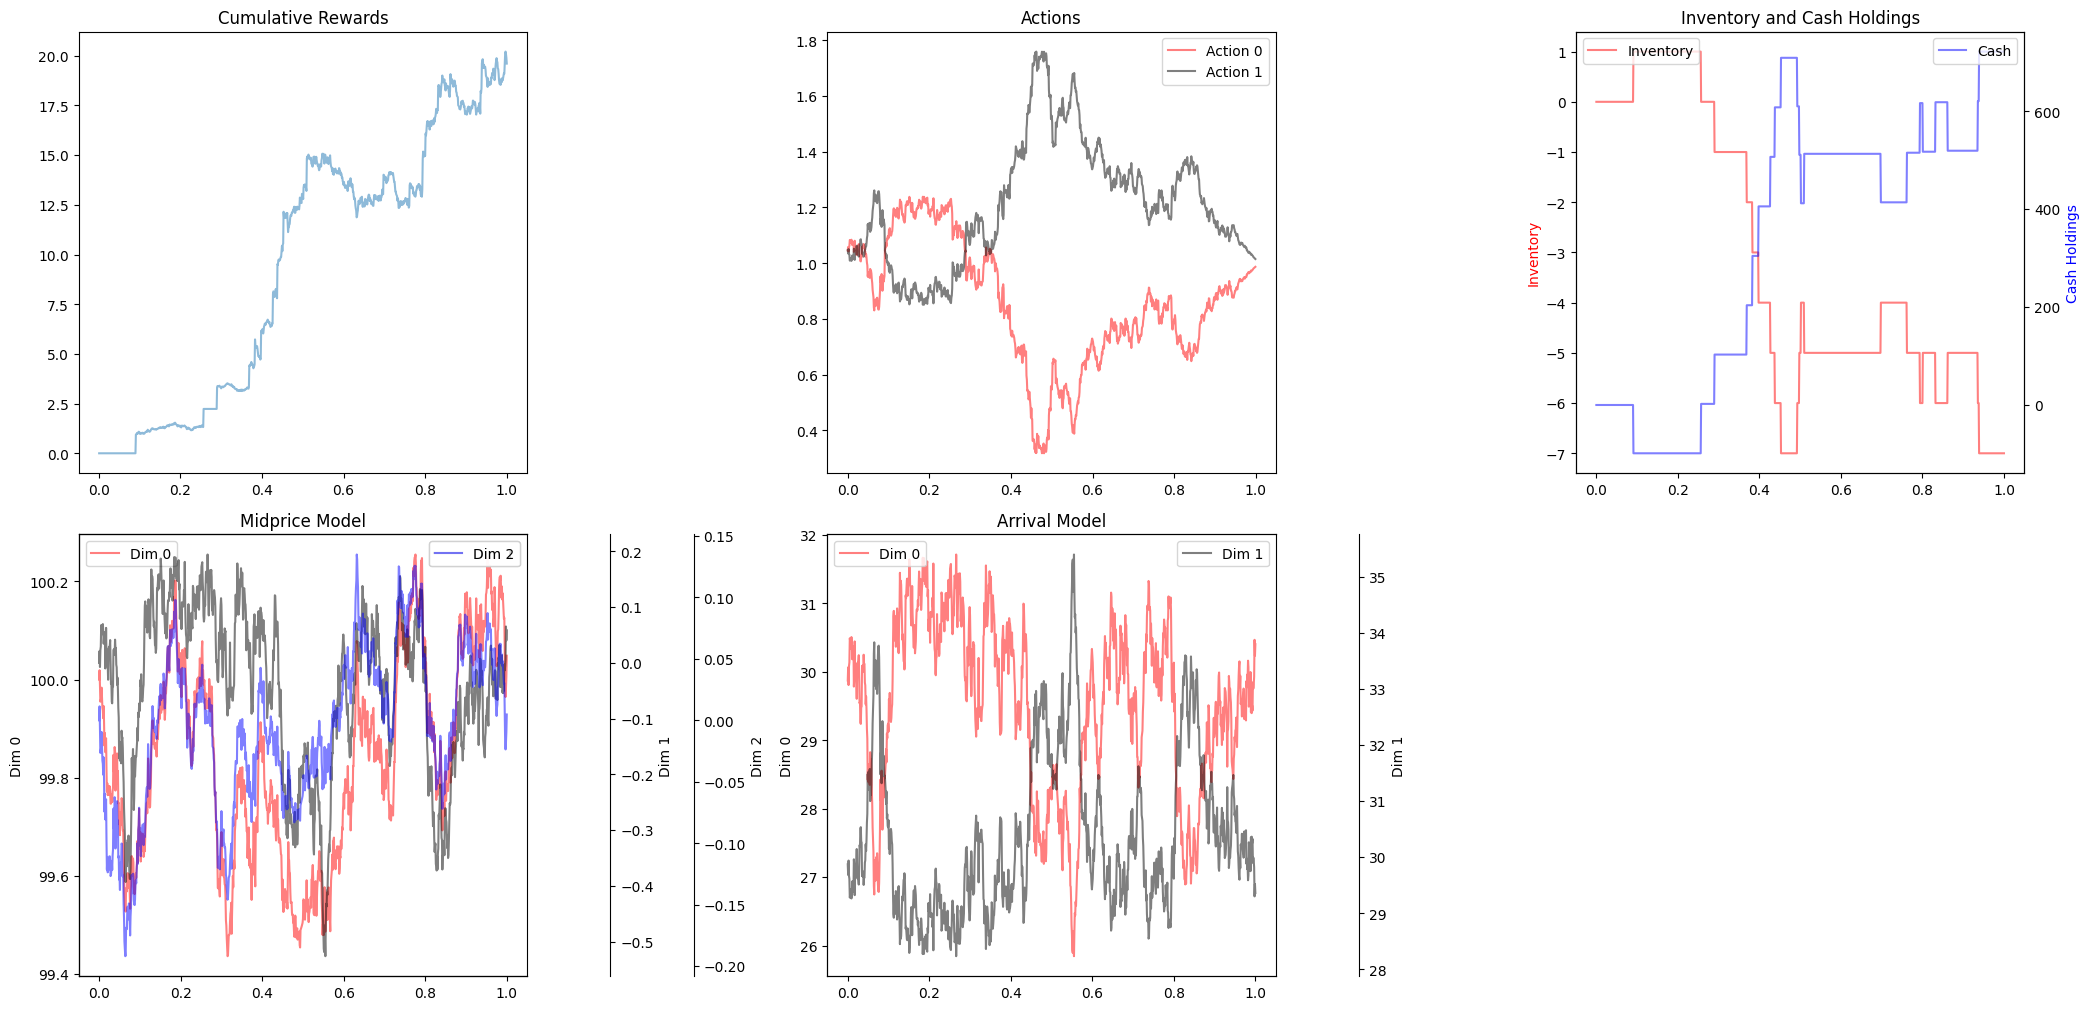

In [21]:
plot_trajectory_extended(fi_env, fi_agent)

In [22]:
num_trajectories = 1000
vec_env_fi = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_agent_fi = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env_fi)

print(vec_env_fi.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


In [23]:
observations_fi, actions_fi, rewards_fi = generate_trajectory(vec_env_fi, vec_agent_fi)

In [24]:
results_fi, fig_fi, total_rewards_fi = generate_results_table_and_hist(vec_env=vec_env_fi,agent=vec_agent_fi)

In [25]:
results_fi

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065432,21.259366,4.896308,-0.098,3.100386


#### Partial Information Agent

In [26]:
pi_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [27]:
pi_agent = OptimizedPartialInfoMMwithFadsInformedUniformedTradersAgent(env=pi_env)
print(pi_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 1000 time points


In [28]:
num_trajectories = 1000
vec_pi_env = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_pi_agent = OptimizedPartialInfoMMwithFadsInformedUniformedTradersAgent(env=vec_pi_env)

print(vec_pi_env.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


In [29]:
observations_pi, actions_pi, rewards_pi = generate_trajectory(vec_pi_env, vec_pi_agent)

In [30]:
results_pi, fig_pi, total_rewards_pi = generate_results_table_and_hist(vec_env=vec_pi_env,agent=vec_pi_agent)

In [31]:
results_pi

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065432,21.145828,4.880012,-0.095,3.106441


### Plot for comparison

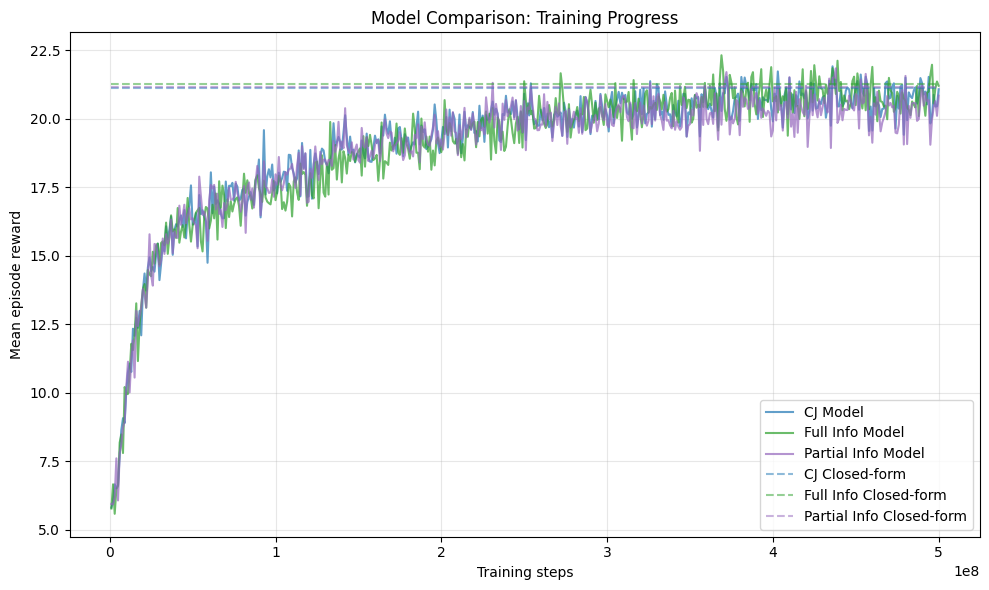

In [33]:
# === Load rollout rewards for all three models ===

# Define the three tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_500_000_000steps_Baseline/2025-10-23_11-40-14/PPO_1/events.out.tfevents.1761212415.MacBookAir.lan.59416.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_500_000_000steps_Baseline/2025-10-26_09-37-37/PPO_1/events.out.tfevents.1761467858.MacBookAir.lan.93550.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_500_000_000steps_Baseline/2025-10-27_08-33-38/PPO_1/events.out.tfevents.1761550419.MacBookAir.lan.11117.0"

# Load event accumulators for each model
ea_cj = event_accumulator.EventAccumulator(cj_rollout_file)
ea_cj.Reload()

ea_full = event_accumulator.EventAccumulator(full_info_rollout_file)
ea_full.Reload()

ea_partial = event_accumulator.EventAccumulator(partial_info_rollout_file)
ea_partial.Reload()

# Extract rollout data for each model
rollout_tag = "rollout/ep_rew_mean"

cj_events = ea_cj.Scalars(rollout_tag)
cj_steps = [e.step for e in cj_events]
cj_rewards = [e.value for e in cj_events]

full_events = ea_full.Scalars(rollout_tag)
full_steps = [e.step for e in full_events]
full_rewards = [e.value for e in full_events]

partial_events = ea_partial.Scalars(rollout_tag)
partial_steps = [e.step for e in partial_events]
partial_rewards = [e.value for e in partial_events]

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Model', alpha=0.7)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Model', alpha=0.7)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Model', alpha=0.7)

# Add baseline lines (closed-form solutions for each model)
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles='--', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles='--', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles='--', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Training Progress')
ax.legend()
plt.tight_layout()
plt.show()

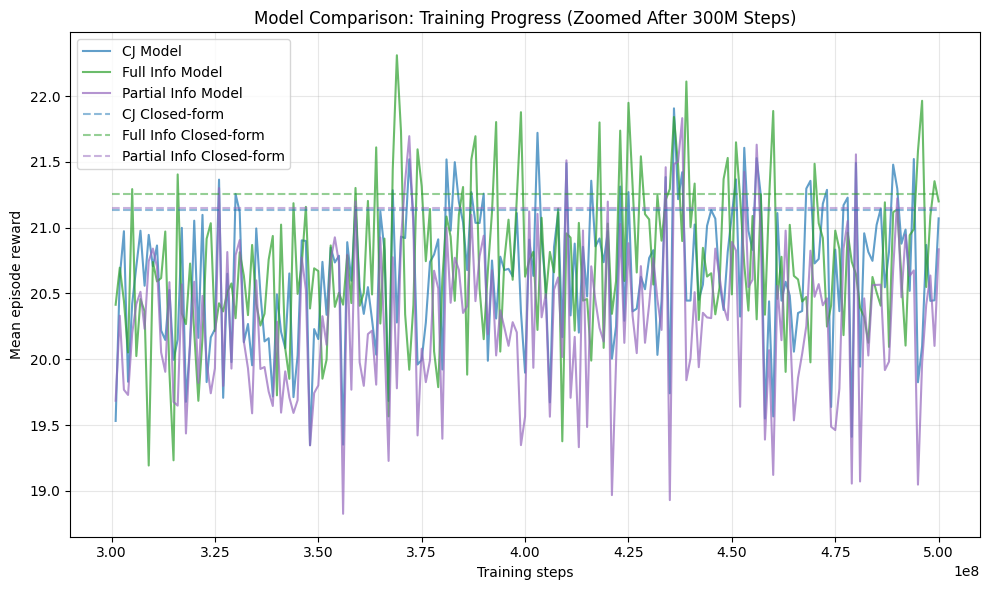

In [34]:
# === Zoomed-in plot after 300M steps ===

zoom_threshold = 300_000_000

# Filter data for steps > 300M
cj_steps_zoom = [s for s in cj_steps if s > zoom_threshold]
cj_rewards_zoom = [r for s, r in zip(cj_steps, cj_rewards) if s > zoom_threshold]

full_steps_zoom = [s for s in full_steps if s > zoom_threshold]
full_rewards_zoom = [r for s, r in zip(full_steps, full_rewards) if s > zoom_threshold]

partial_steps_zoom = [s for s in partial_steps if s > zoom_threshold]
partial_rewards_zoom = [r for s, r in zip(partial_steps, partial_rewards) if s > zoom_threshold]

# === Plot comparison (zoomed) ===
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(cj_steps_zoom, cj_rewards_zoom, '-', color='tab:blue', label='CJ Model', alpha=0.7)
ax.plot(full_steps_zoom, full_rewards_zoom, '-', color='tab:green', label='Full Info Model', alpha=0.7)
ax.plot(partial_steps_zoom, partial_rewards_zoom, '-', color='tab:purple', label='Partial Info Model', alpha=0.7)

# Add closed-form horizontal lines
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

x_min = zoom_threshold
x_max = max(cj_steps + full_steps + partial_steps)

ax.hlines(y=y_line_cj, xmin=x_min, xmax=x_max,
          linestyles='--', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=x_min, xmax=x_max,
          linestyles='--', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=x_min, xmax=x_max,
          linestyles='--', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Training Progress (Zoomed After 300M Steps)')
ax.legend()
plt.tight_layout()
plt.show()


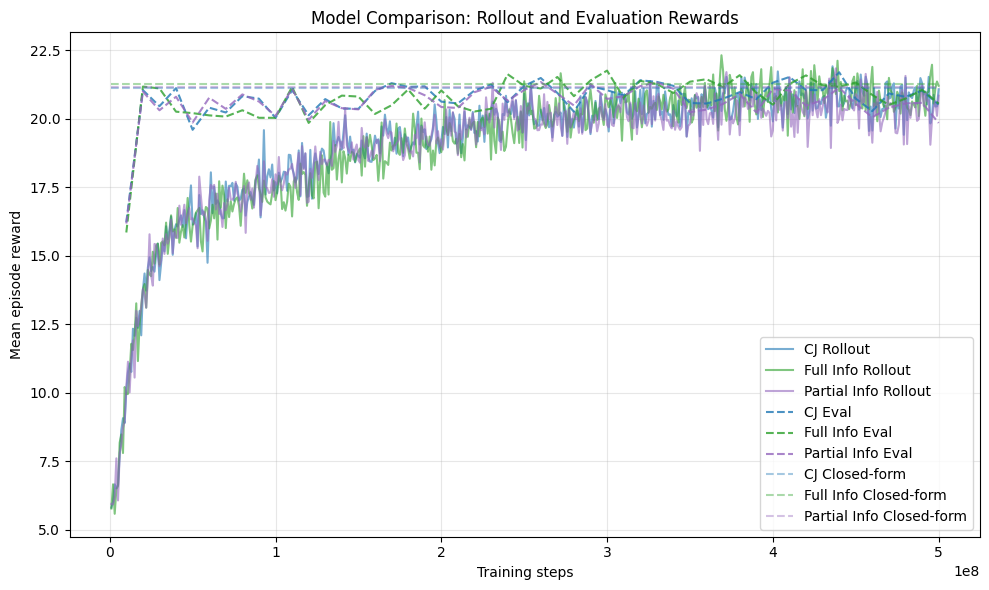

In [35]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import os

# === Define tensorboard event files ===
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_500_000_000steps_Baseline/2025-10-23_11-40-14/PPO_1/events.out.tfevents.1761212415.MacBookAir.lan.59416.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_500_000_000steps_Baseline/2025-10-26_09-37-37/PPO_1/events.out.tfevents.1761467858.MacBookAir.lan.93550.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_500_000_000steps_Baseline/2025-10-27_08-33-38/PPO_1/events.out.tfevents.1761550419.MacBookAir.lan.11117.0"

# === Helper to load data ===
def load_rewards(file_path, rollout_tag="rollout/ep_rew_mean", eval_tag="eval/mean_reward"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    tags = ea.Tags()['scalars']

    rollout_events = ea.Scalars(rollout_tag)
    rollout_steps = [e.step for e in rollout_events]
    rollout_rewards = [e.value for e in rollout_events]

    eval_steps, eval_rewards = [], []
    if eval_tag in tags:
        eval_events = ea.Scalars(eval_tag)
        eval_steps = [e.step for e in eval_events]
        eval_rewards = [e.value for e in eval_events]

    return rollout_steps, rollout_rewards, eval_steps, eval_rewards

# === Load all three models ===
cj_steps, cj_rewards, cj_eval_steps, cj_eval_rewards = load_rewards(cj_rollout_file)
full_steps, full_rewards, full_eval_steps, full_eval_rewards = load_rewards(full_info_rollout_file)
partial_steps, partial_rewards, partial_eval_steps, partial_eval_rewards = load_rewards(partial_info_rollout_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# Rollout rewards (solid lines)
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Rollout', alpha=0.6)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Rollout', alpha=0.6)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Rollout', alpha=0.6)

# Eval rewards (dashed or thinner lines)
if cj_eval_steps:
    ax.plot(cj_eval_steps, cj_eval_rewards, '--', color='tab:blue', alpha=0.8, label='CJ Eval')
if full_eval_steps:
    ax.plot(full_eval_steps, full_eval_rewards, '--', color='tab:green', alpha=0.8, label='Full Info Eval')
if partial_eval_steps:
    ax.plot(partial_eval_steps, partial_eval_rewards, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval')

# Closed-form baseline lines
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles='--', color='tab:blue', label='CJ Closed-form', alpha=0.4)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles='--', color='tab:green', label='Full Info Closed-form', alpha=0.4)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles='--', color='tab:purple', label='Partial Info Closed-form', alpha=0.4)

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Rollout and Evaluation Rewards')
ax.legend()
plt.tight_layout()
plt.show()
